# DATA 620 — Project 1
#### **Course:** DATA 620 — Web Analytics
#### **Assignment:** Project 1


**Group Members:**

Crystal Quezada

Nana Kwasi Danquah

Muhammad Suffyan Khan

# Objective

The objective of the first project is to:

1. Identify and load a network dataset that has some categorical information available for each node.
2. For each of the nodes in the dataset, calculate degree centrality and eigenvector centrality.
3. Compare your centrality measures across your categorical groups.

# Video Presentation

**Video Link:**

# 1. Setup and Imports

Here we import all of the libraries we'll be using.

In [1]:
import pandas as pd
import networkx as nx
import ast

# 2. Load Graph Dataset

After loading the data into dataframes, we add the collaboration data into a network graph, and then we calculate degree centrality and eigenvector centrality.

In [2]:
edges = pd.read_csv("https://raw.githubusercontent.com/crystaliquezada/data620_week2_3/refs/heads/main/edges.csv")
nodes = pd.read_csv("https://raw.githubusercontent.com/crystaliquezada/data620_week2_3/refs/heads/main/nodes.csv")

G = nx.from_pandas_edgelist(
    edges,
    source="id_0",
    target="id_1"
)

degree_cent = nx.degree_centrality(G)
eigen_cent = nx.eigenvector_centrality(G, max_iter=1000)

print(nodes.columns)
nodes.head()

Index(['spotify_id', 'name', 'followers', 'popularity', 'genres',
       'chart_hits'],
      dtype='object')


,spotify_id,name,followers,popularity,genres,chart_hits
0,48WvrUGoijadXXCsGocwM4,Byklubben,1738.0,24,"['nordic house', 'russelater']",['no (3)']
1,4lDiJcOJ2GLCK6p9q5BgfK,Kontra K,1999676.0,72,"['christlicher rap', 'german hip hop']","['at (44)', 'de (111)', 'lu (22)', 'ch (31)', ..."
2,652XIvIBNGg3C0KIGEJWit,Maxim,34596.0,36,[],['de (1)']
3,3dXC1YPbnQPsfHPVkm1ipj,Christopher Martin,249233.0,52,"['dancehall', 'lovers rock', 'modern reggae', ...","['at (1)', 'de (1)']"
4,74terC9ol9zMo8rfzhSOiG,Jakob Hellman,21193.0,39,"['classic swedish pop', 'norrbotten indie', 's...",['se (6)']


# 3. Clean the Data

The following lines of code clean the artist data. We want to ensure that the dataset contains only valid network participants across different music genres. Artists that do not appear in the collaboration network are removed, and the genre data is converted from text into a usable list. A primary genre is then assigned to each artist, and artists with missing genre information are dropped. The code also maps degree centrality and eigenvector centrality values to each artist, removes records with missing centrality measures, and filters out genres with fewer than 10 artists.

In [3]:
nodes = nodes[nodes["spotify_id"].isin(G.nodes())]

def parse_genres(x):
    try:
        return ast.literal_eval(x)
    except:
        return []

nodes["genres"] = nodes["genres"].apply(parse_genres)

nodes["primary_genre"] = nodes["genres"].apply(
    lambda x: x[0] if len(x) > 0 else None
)

nodes = nodes.dropna(subset=["primary_genre"])


In [4]:
nodes["degree_centrality"] = nodes["spotify_id"].map(degree_cent)
nodes["eigenvector_centrality"] = nodes["spotify_id"].map(eigen_cent)

nodes = nodes.dropna(subset=["degree_centrality", "eigenvector_centrality"])

genre_counts = nodes["primary_genre"].value_counts()
valid_genres = genre_counts[genre_counts >= 10].index

nodes = nodes[nodes["primary_genre"].isin(valid_genres)]
nodes.head()



,spotify_id,name,followers,popularity,genres,chart_hits,primary_genre,degree_centrality,eigenvector_centrality
0,48WvrUGoijadXXCsGocwM4,Byklubben,1738.0,24,"[nordic house, russelater]",['no (3)'],nordic house,0.000013,5.831591e-09
3,3dXC1YPbnQPsfHPVkm1ipj,Christopher Martin,249233.0,52,"[dancehall, lovers rock, modern reggae, reggae...","['at (1)', 'de (1)']",dancehall,0.000254,1.794193e-03
4,74terC9ol9zMo8rfzhSOiG,Jakob Hellman,21193.0,39,"[classic swedish pop, norrbotten indie, swedis...",['se (6)'],classic swedish pop,0.000013,5.086154e-08
6,71BhXa24Zf5zcikUb00l2N,Juice,11312.0,37,"[swedish drill, swedish hip hop, swedish trap,...",['se (4)'],swedish drill,0.000026,2.295402e-06
7,3TG1RXLaEhHz5SIPMWahit,Nehuda,36252.0,31,[francoton],['fr (1)'],francoton,0.000026,1.185167e-04


# 4. Group Genres into Broad Categories

Spotify tags artists with very specific micro genres, things like dutch hip hop, french hip hop, and german hip hop, which on their own would give us over a thousand tiny categories. That is far too granular to compare meaningfully, so we map each artist's primary genre into one of ten broad categories based on keyword matching. Anything that does not match a recognized keyword gets grouped into an Other category.

This gives us a small number of categorical groups with enough artists in each one to support a real statistical comparison.

In [5]:
def map_broad_genre(genre):
    genre = genre.lower()
    if "hip hop" in genre or "rap" in genre or "trap" in genre or "drill" in genre:
        return "Hip Hop/Rap"
    if "pop" in genre:
        return "Pop"
    if "rock" in genre or "metal" in genre or "punk" in genre or "grunge" in genre:
        return "Rock/Metal"
    if "electro" in genre or "house" in genre or "techno" in genre or "edm" in genre or "trance" in genre or "dub" in genre or "dance" in genre:
        return "Electronic/Dance"
    if "jazz" in genre or "blues" in genre or "soul" in genre or "funk" in genre or "r&b" in genre or "rnb" in genre:
        return "Jazz/Soul/R&B"
    if "country" in genre or "folk" in genre or "bluegrass" in genre:
        return "Country/Folk"
    if "latin" in genre or "reggaeton" in genre or "corrido" in genre or "banda" in genre or "cumbia" in genre or "salsa" in genre:
        return "Latin"
    if "classical" in genre or "orchestra" in genre or "opera" in genre:
        return "Classical"
    if "reggae" in genre or "dancehall" in genre or "ska" in genre:
        return "Reggae/Dancehall"
    if "indie" in genre or "alternative" in genre or "alt" in genre:
        return "Indie/Alternative"
    return "Other"

nodes["genre_group"] = nodes["primary_genre"].apply(map_broad_genre)

nodes["genre_group"].value_counts()

genre_group
Hip Hop/Rap          11228
Pop                  10123
Other                 9967
Electronic/Dance      4861
Jazz/Soul/R&B         2497
Indie/Alternative     1268
Rock/Metal            1040
Latin                  995
Classical              952
Country/Folk           543
Reggae/Dancehall       262
Name: count, dtype: int64

# 5. Summary Statistics

Before running any formal tests, we look at the overall distribution of both centrality measures, and then break that down by genre group.

In [6]:
import numpy as np

nodes[["degree_centrality", "eigenvector_centrality"]].describe()

,degree_centrality,eigenvector_centrality
count,43736.000000,4.373600e+04
mean,0.000063,8.407023e-04
std,0.000161,4.640497e-03
min,0.000007,1.375708e-35
25%,0.000007,1.024873e-06
50%,0.000013,1.786100e-05
75%,0.000046,1.881061e-04
max,0.011616,1.246736e-01


In [7]:
summary = nodes.groupby("genre_group")[["degree_centrality", "eigenvector_centrality"]].agg(["mean", "median", "std", "count"])
summary

degree_centrality                             \
                               mean    median       std  count   
genre_group                                                      
Classical                  0.000020  0.000007  0.000150    952   
Country/Folk               0.000029  0.000013  0.000046    543   
Electronic/Dance           0.000064  0.000013  0.000166   4861   
Hip Hop/Rap                0.000072  0.000020  0.000149  11228   
Indie/Alternative          0.000033  0.000013  0.000053   1268   
Jazz/Soul/R&B              0.000077  0.000013  0.000226   2497   
Latin                      0.000086  0.000020  0.000159    995   
Other                      0.000054  0.000013  0.000179   9967   
Pop                        0.000068  0.000020  0.000153  10123   
Reggae/Dancehall           0.000027  0.000013  0.000053    262   
Rock/Metal                 0.000038  0.000013  0.000075   1040   

                  eigenvector_centrality                             
                                    mean    median       std  count  
genre_group                                                          
Classical                       0.000021  0.000005  0.000162    952  
Country/Folk                    0.000161  0.000009  0.000472    543  
Electronic/Dance                0.000768  0.000114  0.002334   4861  
Hip Hop/Rap                     0.001278  0.000017  0.006607  11228  
Indie/Alternative               0.000163  0.000004  0.000636   1268  
Jazz/Soul/R&B                   0.000662  0.000060  0.003264   2497  
Latin                           0.003117  0.000038  0.010791    995  
Other                           0.000501  0.000016  0.002758   9967  
Pop                             0.000823  0.000008  0.004389  10123  
Reggae/Dancehall                0.000322  0.000014  0.001108    262  
Rock/Metal                      0.000193  0.000006  0.000734   1040

Both centrality measures are heavily right skewed. Most artists have a fairly low degree and eigenvector centrality, while a small number of highly collaborative, highly connected artists pull the mean well above the median in every genre group. This skew is normal for collaboration networks like this one, where a handful of prolific artists end up working with nearly everyone.

# 6. Visualizing Centrality by Genre Group

Because the centrality values span several orders of magnitude, we plot them on a log scale so that differences between genre groups are easier to see.

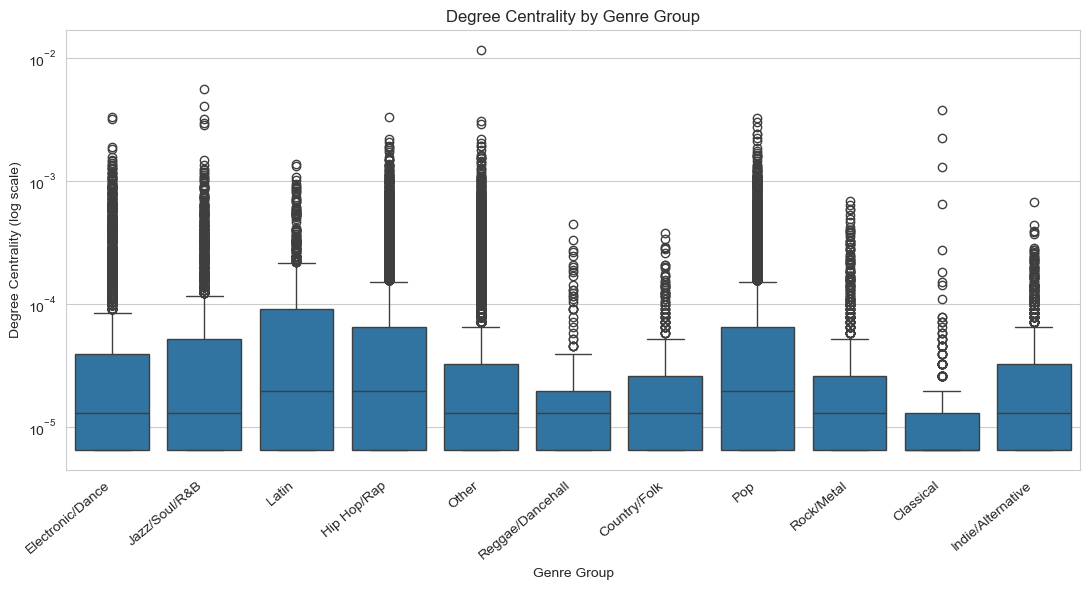

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline

order = nodes.groupby("genre_group")["eigenvector_centrality"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=nodes, x="genre_group", y="degree_centrality", order=order, ax=ax)
ax.set_yscale("log")
ax.set_xlabel("Genre Group")
ax.set_ylabel("Degree Centrality (log scale)")
ax.set_title("Degree Centrality by Genre Group")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()

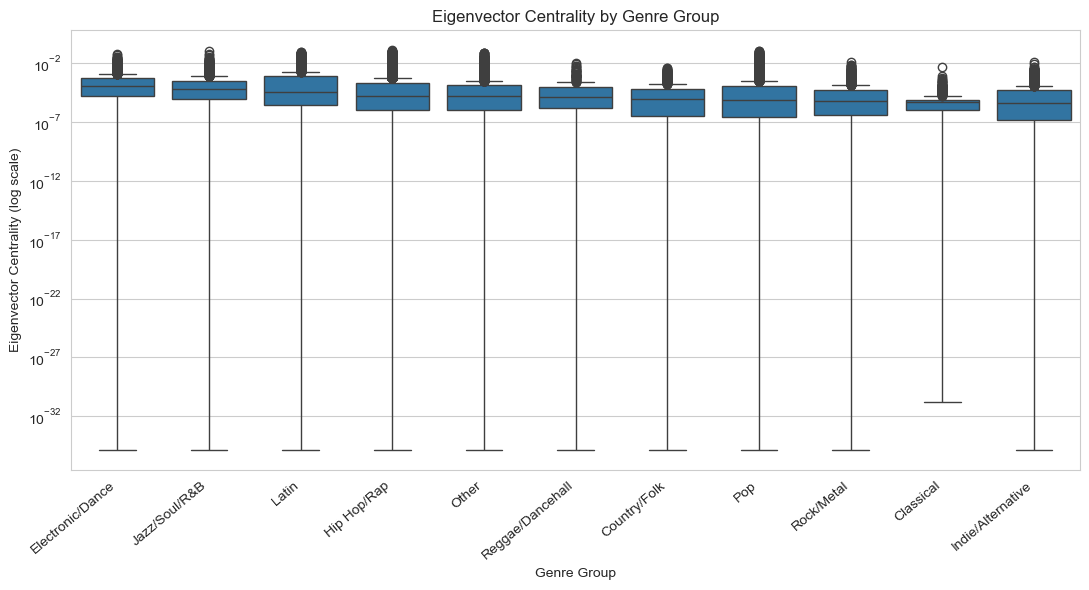

In [9]:
fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=nodes, x="genre_group", y="eigenvector_centrality", order=order, ax=ax)
ax.set_yscale("log")
ax.set_xlabel("Genre Group")
ax.set_ylabel("Eigenvector Centrality (log scale)")
ax.set_title("Eigenvector Centrality by Genre Group")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()

Latin artists stand out with the highest median degree and eigenvector centrality, followed by hip hop and rap, jazz, soul, and r&b. Classical and indie/alternative artists sit at the lower end for eigenvector centrality, suggesting that even when these artists do collaborate, they tend to collaborate with other less central artists rather than with the network's biggest hubs.

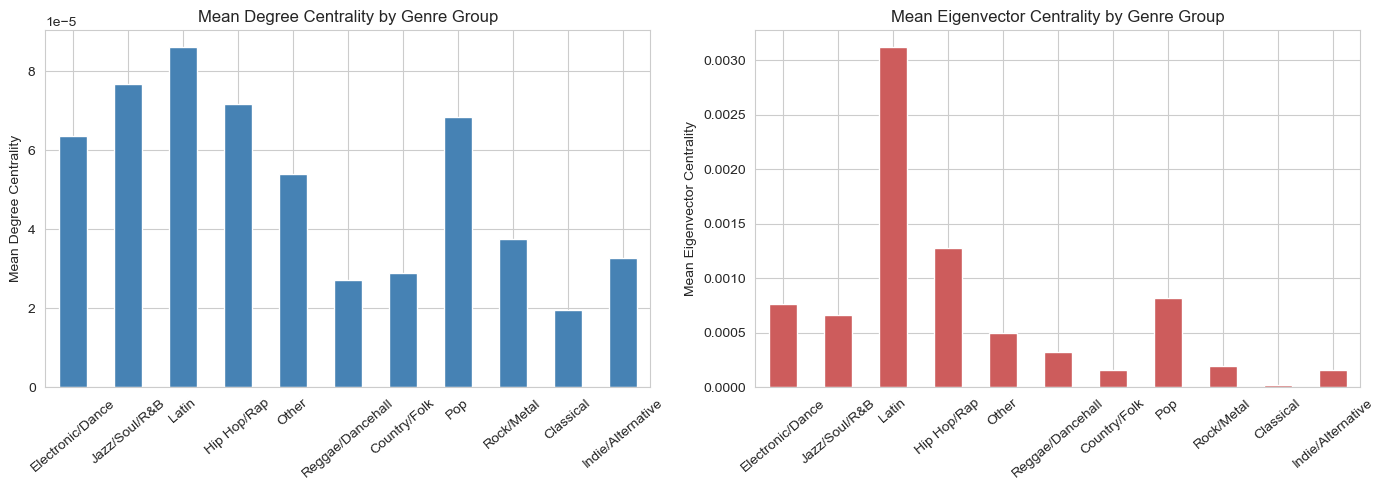

In [10]:
summary_means = nodes.groupby("genre_group")[["degree_centrality", "eigenvector_centrality"]].mean().loc[order]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

summary_means["degree_centrality"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Mean Degree Centrality by Genre Group")
axes[0].set_ylabel("Mean Degree Centrality")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=40)

summary_means["eigenvector_centrality"].plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("Mean Eigenvector Centrality by Genre Group")
axes[1].set_ylabel("Mean Eigenvector Centrality")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=40)

plt.tight_layout()
plt.show()

The mean eigenvector centrality for Latin artists is noticeably higher than every other group, much higher than its median would suggest. That tells us this mean is being pulled upward by a small number of extremely well connected Latin artists rather than reflecting the typical Latin artist in the network.

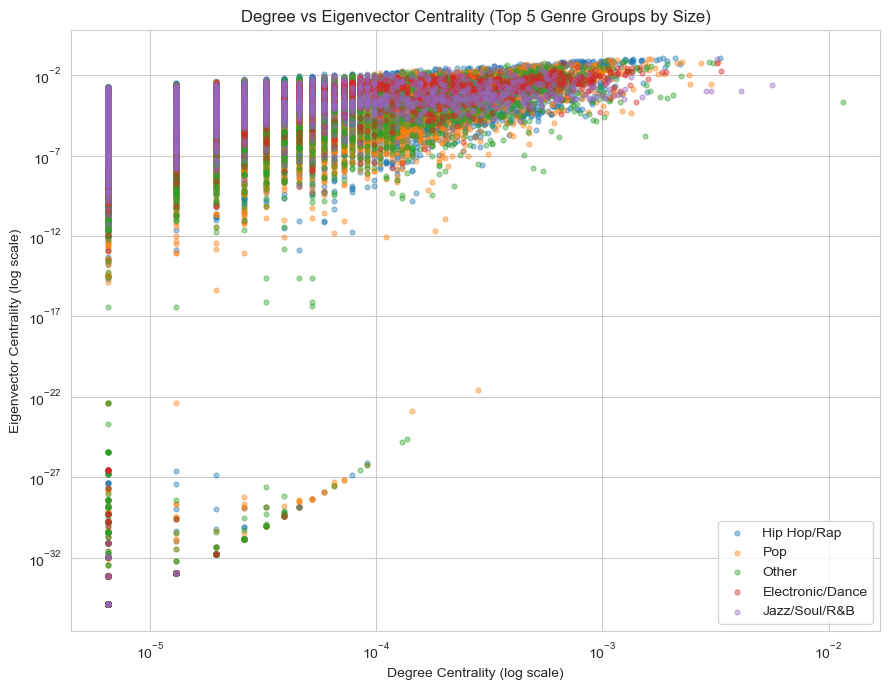

In [11]:
top_groups = nodes["genre_group"].value_counts().head(5).index
subset = nodes[nodes["genre_group"].isin(top_groups)]

fig, ax = plt.subplots(figsize=(9, 7))
for group in top_groups:
    sub = subset[subset["genre_group"] == group]
    ax.scatter(sub["degree_centrality"], sub["eigenvector_centrality"], alpha=0.4, s=12, label=group)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Degree Centrality (log scale)")
ax.set_ylabel("Eigenvector Centrality (log scale)")
ax.set_title("Degree vs Eigenvector Centrality (Top 5 Genre Groups by Size)")
ax.legend()
plt.tight_layout()
plt.show()

There is a clear positive relationship between degree centrality and eigenvector centrality across all five of the largest genre groups, which makes sense since artists with more collaborators tend to also be more central. But the relationship is not perfectly tight. Some artists with relatively few collaborators still reach high eigenvector centrality, because the few people they did collaborate with happen to be extremely well connected themselves.

# 7. Statistical Testing

Now we test whether the differences we are seeing across genre groups are statistically significant, or whether they could just be due to chance.

Since both centrality measures are heavily skewed and clearly not normally distributed, a standard one way ANOVA is not the most appropriate test here. Instead we start with the Kruskal-Wallis test, which is the non-parametric equivalent of an ANOVA and does not assume normally distributed data. It tests whether the centrality distributions differ across all of our genre groups at once.

In [12]:
from scipy import stats

dc_groups = [nodes[nodes["genre_group"] == g]["degree_centrality"] for g in nodes["genre_group"].unique()]
ec_groups = [nodes[nodes["genre_group"] == g]["eigenvector_centrality"] for g in nodes["genre_group"].unique()]

kw_degree = stats.kruskal(*dc_groups)
kw_eigen = stats.kruskal(*ec_groups)

print("Kruskal-Wallis test, degree centrality across genre groups:")
print("  H statistic:", round(kw_degree.statistic, 2), " p-value:", kw_degree.pvalue)
print()
print("Kruskal-Wallis test, eigenvector centrality across genre groups:")
print("  H statistic:", round(kw_eigen.statistic, 2), " p-value:", kw_eigen.pvalue)

Kruskal-Wallis test, degree centrality across genre groups:
  H statistic: 1372.31  p-value: 9.425463338459492e-289

Kruskal-Wallis test, eigenvector centrality across genre groups:
  H statistic: 2496.01  p-value: 0.0


Both tests return p-values far below 0.05, so we can reject the null hypothesis that all genre groups come from the same centrality distribution. In plain terms, genre is associated with real differences in how central an artist tends to be in the collaboration network, for both degree centrality and eigenvector centrality.

Following the example in the assignment, where pairwise comparisons were used to compare specific categories, we now zoom in on the two largest genre groups in our dataset, hip hop and rap versus pop, and run a direct comparison between them.

In [13]:
hiphop_degree = nodes[nodes["genre_group"] == "Hip Hop/Rap"]["degree_centrality"]
pop_degree = nodes[nodes["genre_group"] == "Pop"]["degree_centrality"]

hiphop_eigen = nodes[nodes["genre_group"] == "Hip Hop/Rap"]["eigenvector_centrality"]
pop_eigen = nodes[nodes["genre_group"] == "Pop"]["eigenvector_centrality"]

t_degree = stats.ttest_ind(hiphop_degree, pop_degree, equal_var=False)
t_eigen = stats.ttest_ind(hiphop_eigen, pop_eigen, equal_var=False)

u_degree = stats.mannwhitneyu(hiphop_degree, pop_degree)
u_eigen = stats.mannwhitneyu(hiphop_eigen, pop_eigen)

print("Hip Hop/Rap vs Pop, degree centrality")
print("  Welch t-test:      t =", round(t_degree.statistic, 3), " p =", round(t_degree.pvalue, 4))
print("  Mann-Whitney U:     p =", round(u_degree.pvalue, 4))
print("  Hip Hop/Rap mean:", hiphop_degree.mean(), " Pop mean:", pop_degree.mean())
print()
print("Hip Hop/Rap vs Pop, eigenvector centrality")
print("  Welch t-test:      t =", round(t_eigen.statistic, 3), " p =", t_eigen.pvalue)
print("  Mann-Whitney U:     p =", u_eigen.pvalue)
print("  Hip Hop/Rap mean:", hiphop_eigen.mean(), " Pop mean:", pop_eigen.mean())

Hip Hop/Rap vs Pop, degree centrality
  Welch t-test:      t = 1.622  p = 0.1049
  Mann-Whitney U:     p = 0.0264
  Hip Hop/Rap mean: 7.176056868865012e-05  Pop mean: 6.840325599807806e-05

Hip Hop/Rap vs Pop, eigenvector centrality
  Welch t-test:      t = 5.985  p = 2.196912982555255e-09
  Mann-Whitney U:     p = 3.0730008915876307e-50
  Hip Hop/Rap mean: 0.001278464060597336  Pop mean: 0.0008230036408124211


For degree centrality, the Welch t-test does not find a significant difference between hip hop and rap artists and pop artists (p is above 0.05), even though the non-parametric Mann-Whitney test does pick up a significant difference. This kind of disagreement between tests is common with skewed data, where a t-test on means can be dominated by a few extreme outliers while a rank-based test like Mann-Whitney is more sensitive to the bulk of the distribution.

For eigenvector centrality, both tests agree, with p-values far below 0.05. Hip hop and rap artists have meaningfully higher eigenvector centrality on average than pop artists. That means that even though the typical hip hop or rap artist might not have dramatically more direct collaborators than a pop artist, the collaborators they do have tend to be more central figures in the network. This fits with how the genre operates in practice, where it is common for rap and hip hop artists to feature on each other's tracks, repeatedly linking back to the same small set of highly connected, prolific collaborators.

# 8. Most Central Artists

To put some real names behind these numbers, we look at which artists have the highest eigenvector centrality overall, and which artist is the most central within each genre group.

In [14]:
nodes.nlargest(5, "eigenvector_centrality")[["name", "genre_group", "primary_genre", "degree_centrality", "eigenvector_centrality"]]

,name,genre_group,primary_genre,degree_centrality,eigenvector_centrality
7897,Farruko,Hip Hop/Rap,latin hip hop,0.001852,0.124674
15578,French Montana,Hip Hop/Rap,gangster rap,0.002087,0.117454
8030,Gucci Mane,Hip Hop/Rap,atl hip hop,0.003320,0.113027
4264,Ty Dolla $ign,Pop,dance pop,0.001644,0.108986
16851,Lil Wayne,Hip Hop/Rap,hip hop,0.001781,0.105402


In [15]:
top_per_group = nodes.loc[nodes.groupby("genre_group")["eigenvector_centrality"].idxmax()]
top_per_group[["genre_group", "name", "primary_genre", "degree_centrality", "eigenvector_centrality"]].sort_values("eigenvector_centrality", ascending=False)

,genre_group,name,primary_genre,degree_centrality,eigenvector_centrality
7897,Hip Hop/Rap,Farruko,latin hip hop,0.001852,0.124674
4264,Pop,Ty Dolla $ign,dance pop,0.001644,0.108986
19434,Jazz/Soul/R&B,Snoop Dogg,g funk,0.003228,0.102871
18411,Latin,J Balvin,reggaeton,0.001337,0.098754
14983,Other,El Alfa,dembow,0.001024,0.079859
7956,Electronic/Dance,Diplo,edm,0.003222,0.059576
16782,Indie/Alternative,Kiiara,alt z,0.000385,0.013716
3610,Rock/Metal,Santana,blues rock,0.000691,0.012283
15119,Reggae/Dancehall,R. City,reggae fusion,0.000170,0.010228
18142,Classical,Andrea Bocelli,classical tenor,0.002231,0.004806


The most centrally connected artists overall are dominated by hip hop and rap, with Farruko, French Montana, Gucci Mane, and Lil Wayne all appearing in the top five. This lines up with what the statistical tests showed us. It is also worth noting that the most central Latin artist, J Balvin, has an eigenvector centrality close to the highest in the entire network, which helps explain why the Latin genre group's mean eigenvector centrality was so much higher than its median earlier in the notebook.

# 9. Conclusion

Our analysis of the Spotify artist collaboration network shows that genre is meaningfully associated with how central an artist is within the network. Using Kruskal-Wallis tests, we found statistically significant differences in both degree centrality and eigenvector centrality across genre groups. Latin and hip hop/rap artists tend to sit closer to the center of the network, while genres like classical and indie/alternative tend to sit further out on the periphery.

Comparing the two largest genre groups directly, hip hop/rap and pop, we found that the two genres do not differ as clearly in raw degree centrality, but hip hop and rap artists have significantly higher eigenvector centrality. In other words, hip hop and rap artists tend to be connected to other highly connected artists more often than pop artists are, even when they have a similar number of direct collaborators. This reflects the collaborative culture of hip hop and rap, where features and guest verses repeatedly link artists back to a small core of highly prolific, highly connected figures in the genre.

One limitation worth noting is that we used each artist's first listed genre tag as their primary genre, and then grouped hundreds of specific micro genres into ten broader categories using keyword matching. This simplification makes the comparison statistically tractable, but it does mean that some artists may have been placed into a broader category that does not perfectly reflect their musical style, and the Other category in particular is something of a catch-all.